# TimesFM 3.0 - Leaching reactor forecast

It reads the full-resolution `h5` files from `Leaching-DataGen.ipynb`, **downsamples**, then forecasts
the states (and pH) over some horizon given past states + past-and-future inputs.


In [6]:
# %% Setup
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # avoid libomp double-init abort (numpy and torch both bundle OpenMP on macOS)
os.environ.setdefault("OMP_NUM_THREADS", "1")           # avoids an OMP pthread_mutex_init segfault during inference on macOS

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
from timesfm3 import TimesFM3Forecaster

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = TimesFM3Forecaster.from_pretrained("google/timesfm-3.0-pytorch", device=device)
print(f"Loaded TimesFM 3.0 on {device}")

Loaded TimesFM 3.0 on cpu


In [7]:
# %% Load and align data: states (targets) + exogenous inputs (covariates)
# Downsampling is done HERE (not in a separate file). Raw dt = 0.1 min, so DOWNSAMPLE = 10 -> 1 min
# effective, ~10 samples per residence time constant (tau = 10 min). That keeps the faster acid
# transient (~2 min) resolved as well - set DOWNSAMPLE = 20 for his native 2 min pH rate if you prefer
# fewer points. States and inputs were written on the SAME grid, so a single stride aligns them (no offset).
STATE_COLUMNS = {"C_Cu_aq": "C_Cu_aq", "C_H": "C_H", "C_Cu_s": "C_Cu_s", "pH": "pH"}
EXOG_COLUMNS  = {"q_H": "q_H", "F": "F", "C_H_in": "C_H_in", "C_Cu_s_in": "C_Cu_s_in"}

DOWNSAMPLE = 10          # raw dt = 0.1 min -> effective dt = DOWNSAMPLE * 0.1 min
DT_MIN = 0.1
FREQ = f"{int(DOWNSAMPLE * DT_MIN * 60)}s"     # pandas timestamp spacing (60s here)

with h5py.File("Leaching_SimulationData.h5", "r") as f:
    data = {col: f[key][::DOWNSAMPLE, 0] for key, col in STATE_COLUMNS.items()}
    n = len(data["C_H"])

with h5py.File("Leaching_InputVectors.h5", "r") as f:
    for key, col in EXOG_COLUMNS.items():
        data[col] = f[key][::DOWNSAMPLE, 0]
    flags = {key: f[f"{key}.plt"][::DOWNSAMPLE] for key in EXOG_COLUMNS}

df = pd.DataFrame(data)
df["item_id"] = "leach"
df["timestamp"] = pd.date_range("2026-01-01", periods=n, freq=FREQ)
df = df[["item_id", "timestamp"] + list(STATE_COLUMNS.values()) + list(EXOG_COLUMNS.values())]
df.head()

,item_id,timestamp,C_Cu_aq,C_H,C_Cu_s,pH,q_H,F,C_H_in,C_Cu_s_in
0,leach,2026-01-01 00:00:00,1.918898,0.631102,6.081102,0.339787,2.5,1.0,0.05,8.0
1,leach,2026-01-01 00:01:00,1.918898,0.631102,6.081102,0.307399,2.5,1.0,0.05,8.0
2,leach,2026-01-01 00:02:00,1.918898,0.631102,6.081102,0.289293,2.5,1.0,0.05,8.0
3,leach,2026-01-01 00:03:00,1.918898,0.631102,6.081102,0.387799,2.5,1.0,0.05,8.0
4,leach,2026-01-01 00:04:00,1.918898,0.631102,6.081102,0.558069,2.5,1.0,0.05,8.0


In [8]:
# %% Pick a forecast window
events = []
for key in EXOG_COLUMNS:
    active = np.where(flags[key] > 0)[0]
    if len(active) == 0:
        continue
    breaks = np.where(np.diff(active) > 1)[0]
    starts = np.concatenate([[active[0]], active[breaks + 1]])
    ends = np.concatenate([active[breaks], [active[-1]]])
    events += [(s, e, EXOG_COLUMNS[key]) for s, e in zip(starts, ends)]
events.sort()

EVENT_INDEX = -6      # which input event to forecast across, in time order; -1 = last = most context
BUFFER = 50           # samples of steady state before the event kept inside the forecast window (not the context)
PLOT_LEAD_IN = 300    # samples of history shown in the plot before the forecast - display only
HORIZON = None        # forecast horizon in samples - set an int yourself, or leave None to size it to the event

event_start, event_end, event_name = events[EVENT_INDEX]
SPLIT = max(event_start - BUFFER, 0)          # everything before this is context
context_available = SPLIT
context_used = min(context_available, pipeline.global_context)
if HORIZON is None:
    HORIZON = min((event_end - SPLIT) + 300, n - SPLIT)   # TimesFM 3.0 stitches output patches, so no fixed max prediction length

print(
    f"Forecasting across the {event_name} event: {context_available} samples of context available "
    f"({context_used} will actually be used - model max is {pipeline.global_context}), horizon = {HORIZON} steps"
)

Forecasting across the q_H event: 4022 samples of context available (4022 will actually be used - model max is 15360), horizon = 482 steps


In [9]:
# %% Run TimesFM 3.0 with past states + past-and-future exogenous inputs
# TimesFM 3.0 is natively multivariate: the 4 states go in as target variates of a single
# (variates, context) array and the 4 inputs as past-and-future covariate channels, so one call
# covers every state. Context is sliced to context_used here so the covariate array stays aligned
# with the target.
QUANTILES = [0.1, 0.5, 0.9]

context_df = df.iloc[SPLIT - context_used:SPLIT].copy()
future_df  = df.iloc[SPLIT:SPLIT + HORIZON][["item_id", "timestamp"] + list(EXOG_COLUMNS.values())].copy()
truth_df   = df.iloc[SPLIT:SPLIT + HORIZON].copy()

target = context_df[list(STATE_COLUMNS.values())].to_numpy(dtype=np.float32).T          # (4, context_used)
past_future_cov = np.concatenate([                                                       # (4, context_used + HORIZON)
    context_df[list(EXOG_COLUMNS.values())].to_numpy(dtype=np.float32),
    future_df[list(EXOG_COLUMNS.values())].to_numpy(dtype=np.float32),
]).T

out = pipeline.predict(
    target,
    horizon=HORIZON,
    past_future_covariates=past_future_cov,
    return_quantiles=True,
)   # out.forecast: (4, HORIZON) median, out.quantiles: (4, HORIZON, 9) for deciles 0.1 .. 0.9

q_index = {q: pipeline.config.quantiles.index(q) for q in QUANTILES}
pred_df = pd.concat(
    [
        pd.DataFrame({
            "item_id": "leach",
            "timestamp": truth_df["timestamp"].values,
            "target_name": col,
            "predictions": out.forecast[v],
            **{str(q): out.quantiles[v, :, i] for q, i in q_index.items()},
        })
        for v, col in enumerate(STATE_COLUMNS.values())
    ],
    ignore_index=True,
)
pred_df.head()

,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,leach,2026-01-03 19:02:00,C_Cu_aq,1.918980,1.917381,1.918980,1.920962
1,leach,2026-01-03 19:03:00,C_Cu_aq,1.918014,1.916528,1.918014,1.919357
2,leach,2026-01-03 19:04:00,C_Cu_aq,1.919206,1.916918,1.919206,1.920437
3,leach,2026-01-03 19:05:00,C_Cu_aq,1.918967,1.916877,1.918967,1.920308
4,leach,2026-01-03 19:06:00,C_Cu_aq,1.918239,1.916006,1.918239,1.919172


C_Cu_aq: MAE = 0.014979
C_H: MAE = 0.013049
C_Cu_s: MAE = 0.048516
pH: MAE = 0.19593


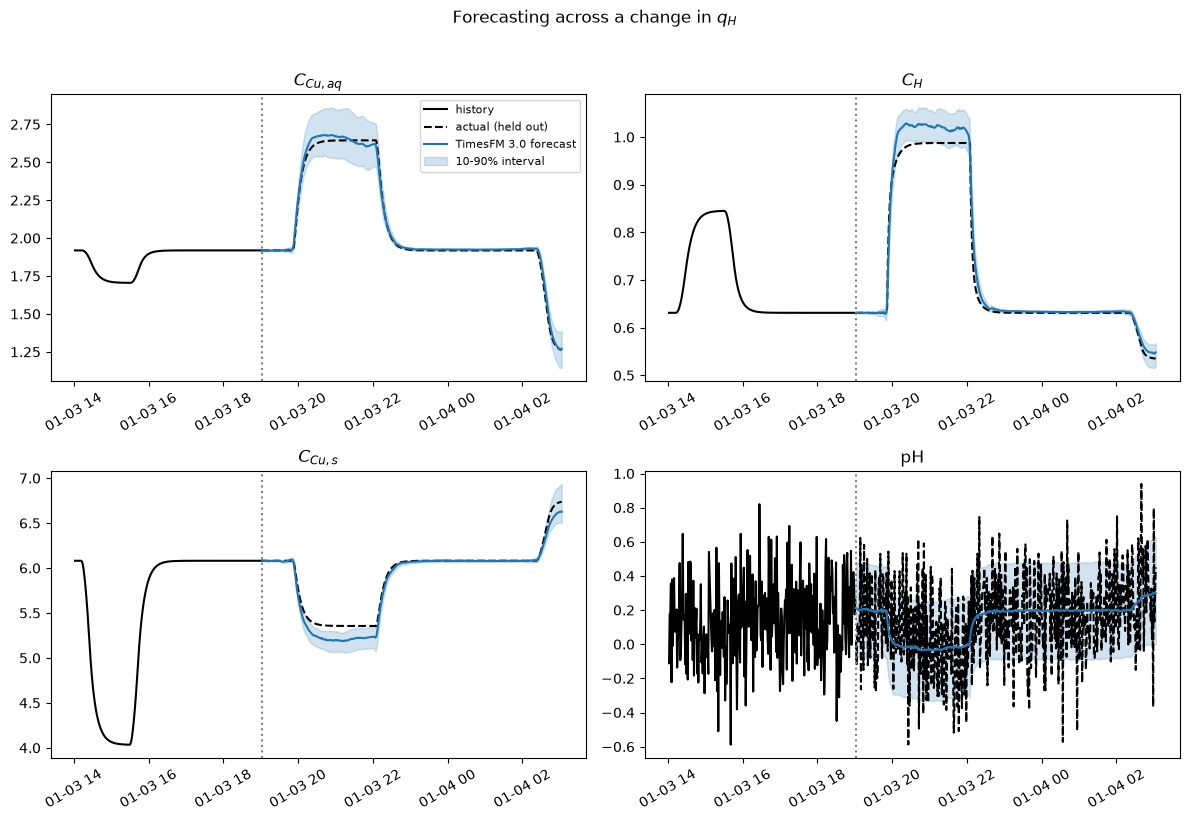

In [10]:
# %% Accuracy vs. the held-out actual simulation, and plots per state
for col in STATE_COLUMNS.values():
    sub = pred_df[pred_df["target_name"] == col].reset_index(drop=True)
    mae = np.mean(np.abs(sub["predictions"].values - truth_df[col].values))
    print(f"{col}: MAE = {mae:.5g}")

def subscript_label(name):
    # render e.g. "C_Cu_aq" as "$C_{Cu,aq}$" so multi-part variable names show as real subscripts
    parts = name.split("_")
    return name if len(parts) == 1 else f"${parts[0]}_{{{','.join(parts[1:])}}}$"

context_tail = context_df.iloc[-PLOT_LEAD_IN:]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), STATE_COLUMNS.values()):
    sub = pred_df[pred_df["target_name"] == col]
    ax.plot(context_tail["timestamp"], context_tail[col], color="black", label="history")
    ax.plot(truth_df["timestamp"], truth_df[col], color="black", linestyle="--", label="actual (held out)")
    ax.plot(sub["timestamp"], sub["predictions"], color="tab:blue", label="TimesFM 3.0 forecast")
    ax.fill_between(sub["timestamp"], sub["0.1"], sub["0.9"], color="tab:blue", alpha=0.2, label="10-90% interval")
    ax.axvline(truth_df["timestamp"].iloc[0], color="gray", linestyle=":")
    ax.set_title(subscript_label(col))
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle(f"Forecasting across a change in {subscript_label(event_name)}", y=1.02)
fig.tight_layout()